# Financial Labeling: CUSUM, Triple Barriers, and Trading

This notebook answers three questions:

1. **When** has the market moved enough to create a new observation?
2. **How** do we label that observation using an economically meaningful exit rule?
3. **What happens** when those rules are connected to a simple trading signal?


## 1. Setup and price data

The loader first looks for a local pickle file. If it is not available, it creates a reproducible synthetic price series so every cell can still run. Replace `DATA_PATH` or `TICKER` as needed.

In [5]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

TICKER = 'AAPL'

DATA_PATH = (
    Path.cwd().parent
    / "Week1 - Numpy and Pandas"
    / "ticker_data_dict.pkl"
)
def load_close(ticker=TICKER, data_path=DATA_PATH):
    candidates = [data_path, Path('ticker_data_dict.pkl')]
    for path in candidates:
        if path.exists():
            with path.open('rb') as file:
                data = pickle.load(file)
            asset = data[ticker]
            close = asset['Close'] if isinstance(asset, pd.DataFrame) else asset
            close = pd.Series(close, dtype=float).dropna().sort_index()
            close.index = pd.to_datetime(close.index)
            return close.rename(ticker), f'local data: {path}'


close, data_source = load_close()
print(f'Using {data_source}; {len(close):,} observations from {close.index.min().date()} to {close.index.max().date()}.')
close.head()

Using local data: g:\My Drive\Teaching\Math 628- Fall 2026\New Github\Math_628_Fall_2026\Week1 - Numpy and Pandas\ticker_data_dict.pkl; 4,977 observations from 2005-11-14 to 2025-08-27.


Date
2005-11-14   1.8447
2005-11-15   1.8697
2005-11-16   1.9498
2005-11-17   1.9369
2005-11-18   1.9381
Name: AAPL, dtype: float64

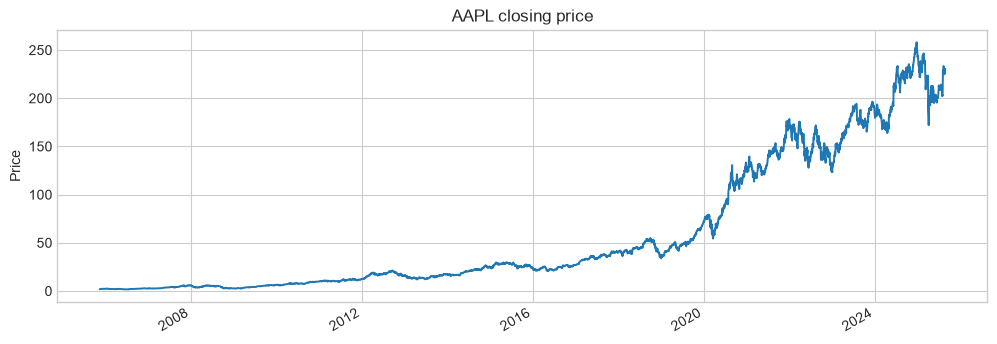

In [6]:
ax = close.plot(figsize=(12, 4), lw=1.4, title=f'{close.name} closing price')
ax.set(xlabel='', ylabel='Price')
plt.show()

## 2. Why use a CUSUM filter?

Sampling every day treats quiet and turbulent days as equally informative. It also creates many nearly redundant observations. A symmetric cumulative-sum (CUSUM) filter samples in **event time**: it emits an event only after accumulated price movement exceeds a threshold.

For log-price changes $\Delta p_t$, maintain positive and negative sums

$$S_t^+ = \max(0, S_{t-1}^+ + \Delta p_t), \qquad S_t^- = \min(0, S_{t-1}^- + \Delta p_t).$$

An event occurs when $S_t^+ > h_t$ or $S_t^- < -h_t$. After a hit, that sum is reset. We scale $h_t$ by recent volatility, so the filter demands a larger absolute move in volatile markets.

**Why it is useful:** fewer redundant samples, more attention to economically meaningful moves, and a threshold that adapts to market conditions. CUSUM chooses event times; it does **not** decide whether to buy or sell.

In [7]:
def daily_volatility(close, span=30):
    """Exponentially weighted volatility of one-period log returns."""
    return np.log(close).diff().ewm(span=span, min_periods=span).std()

def cusum_filter(log_price, threshold):
    """Return timestamps at which a symmetric CUSUM process crosses its threshold."""
    changes, limits = log_price.diff().align(threshold, join='inner')
    positive_sum = 0.0
    negative_sum = 0.0
    events = []

    for timestamp, change in changes.dropna().items():
        limit = limits.loc[timestamp]
        if pd.isna(limit) or limit <= 0:
            continue
        positive_sum = max(0.0, positive_sum + change)
        negative_sum = min(0.0, negative_sum + change)

        if positive_sum > limit:
            positive_sum = 0.0
            events.append(timestamp)
        elif negative_sum < -limit:
            negative_sum = 0.0
            events.append(timestamp)

    return pd.DatetimeIndex(events).drop_duplicates()

In [10]:
VOLATILITY_SPAN = 30
CUSUM_MULTIPLIER = 2.0

volatility = daily_volatility(close, span=VOLATILITY_SPAN)
threshold = CUSUM_MULTIPLIER * volatility
event_times = cusum_filter(np.log(close), threshold)

print(f'Calendar observations: {len(close):,}')
print(f'CUSUM events:         {len(event_times):,}')
print(f'Sampling ratio:       {len(event_times) / len(close):.1%}')

Calendar observations: 4,977
CUSUM events:         939
Sampling ratio:       18.9%


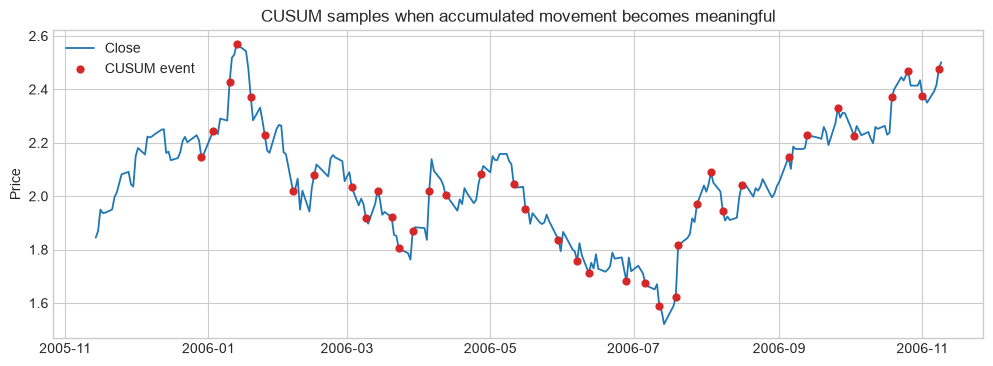

In [11]:
window = close.iloc[:250]
visible_events = event_times.intersection(window.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(window.index, window, lw=1.3, label='Close')
ax.scatter(visible_events, close.loc[visible_events], s=24, color='tab:red', label='CUSUM event', zorder=3)
ax.set(title='CUSUM samples when accumulated movement becomes meaningful', ylabel='Price', xlabel='')
ax.legend()
plt.show()

## 3. Triple-barrier labeling

CUSUM tells us **when an event begins**. Triple-barrier labeling determines **how it ends**. At event time $t_0$, we place three barriers:

- profit-taking: $+m_{pt}\sigma_{t_0}$,
- stop-loss: $-m_{sl}\sigma_{t_0}$,
- vertical barrier: a maximum holding date $t_0 + H$.

The first barrier touched determines the outcome. Here, `+1` means profit-taking was touched first, `-1` means stop-loss was touched first, and `0` means neither horizontal barrier was touched before time expired. Volatility-scaled widths make events more comparable across regimes.

> A label describes a future outcome and is a target for analysis. It is not information available at entry time and therefore is not itself a tradable signal.

In [12]:
def add_vertical_barrier(close, events, holding_days=20):
    """Map each event to the first observed date on or after t0 + holding_days."""
    candidate_positions = close.index.searchsorted(events + pd.Timedelta(days=holding_days))
    valid = candidate_positions < len(close)
    return pd.Series(close.index[candidate_positions[valid]], index=events[valid], name='vertical_time')

def triple_barrier_labels(close, events, target, vertical_times, pt=1.0, sl=1.0, side=None):
    """Apply volatility-scaled barriers; side=+1 for long and -1 for short."""
    rows = []
    if side is None:
        side = pd.Series(1.0, index=events)

    usable_events = events.intersection(vertical_times.index).intersection(target.dropna().index)
    for start in usable_events:
        end = vertical_times.loc[start]
        width = float(target.loc[start])
        trade_side = float(side.reindex([start]).iloc[0])
        if not np.isfinite(width) or width <= 0 or trade_side == 0:
            continue

        path = close.loc[start:end] / close.loc[start] - 1.0
        signed_path = trade_side * path
        pt_hits = signed_path[signed_path >= pt * width]
        sl_hits = signed_path[signed_path <= -sl * width]
        pt_time = pt_hits.index[0] if len(pt_hits) else pd.NaT
        sl_time = sl_hits.index[0] if len(sl_hits) else pd.NaT

        candidates = [(end, 0, 'vertical')]
        if pd.notna(pt_time):
            candidates.append((pt_time, 1, 'profit_taking'))
        if pd.notna(sl_time):
            candidates.append((sl_time, -1, 'stop_loss'))
        exit_time, label, barrier = min(candidates, key=lambda item: item[0])
        raw_return = close.loc[exit_time] / close.loc[start] - 1.0

        rows.append({
            'event_time': start, 'exit_time': exit_time, 'vertical_time': end,
            'target': width, 'side': trade_side, 'barrier': barrier, 'label': label,
            'raw_return': raw_return, 'strategy_return': trade_side * raw_return,
            'holding_days': (exit_time - start).days
        })

    return pd.DataFrame(rows).set_index('event_time').sort_index()

In [13]:
HOLDING_DAYS = 20
PROFIT_TAKING = 1.0
STOP_LOSS = 1.0

vertical_times = add_vertical_barrier(close, event_times, holding_days=HOLDING_DAYS)
labels = triple_barrier_labels(
    close=close, events=event_times, target=volatility, vertical_times=vertical_times,
    pt=PROFIT_TAKING, sl=STOP_LOSS
)
labels.head()

,exit_time,vertical_time,target,side,barrier,label,raw_return,strategy_return,holding_days
event_time,,,,,,,,,
2005-12-29,2006-01-03,2006-01-18,0.0187,1.0000,profit_taking,1,0.0462,0.0462,5
2006-01-03,2006-01-06,2006-01-23,0.0200,1.0000,profit_taking,1,0.0207,0.0207,3
2006-01-10,2006-01-11,2006-01-30,0.0232,1.0000,profit_taking,1,0.0376,0.0376,1
2006-01-13,2006-01-18,2006-02-02,0.0221,1.0000,stop_loss,-1,-0.0362,-0.0362,5
2006-01-19,2006-01-20,2006-02-08,0.0256,1.0000,stop_loss,-1,-0.0373,-0.0373,1


,count,share
label,,
stop loss,394,0.4205
vertical,12,0.0128
profit taking,531,0.5667


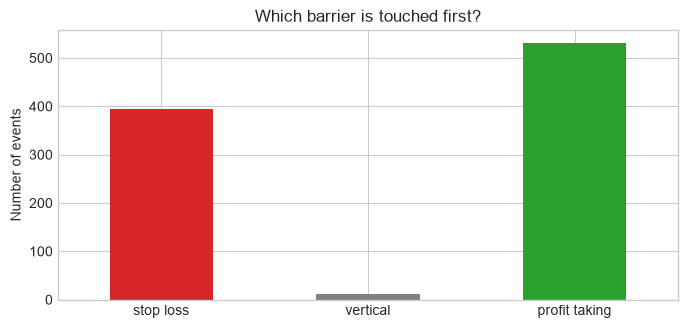

In [14]:
label_names = {-1: 'stop loss', 0: 'vertical', 1: 'profit taking'}
label_counts = labels['label'].map(label_names).value_counts().reindex(label_names.values(), fill_value=0)
display(pd.DataFrame({'count': label_counts, 'share': label_counts / label_counts.sum()}))

ax = label_counts.plot.bar(figsize=(8, 3.5), color=['tab:red', 'tab:gray', 'tab:green'])
ax.set(title='Which barrier is touched first?', xlabel='', ylabel='Number of events')
ax.tick_params(axis='x', rotation=0)
plt.show()

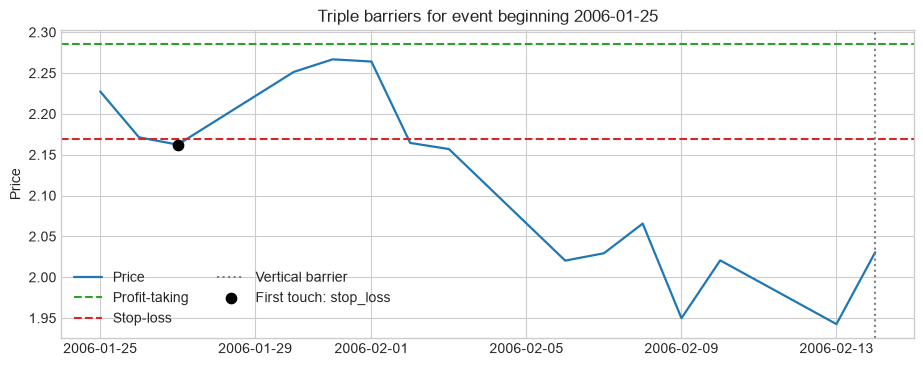

In [15]:
def plot_labeled_event(close, result_row):
    start = result_row.name
    vertical = result_row['vertical_time']
    exit_time = result_row['exit_time']
    start_price = close.loc[start]
    width = result_row['target']
    path = close.loc[start:vertical]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(path.index, path, lw=1.6, label='Price')
    ax.axhline(start_price * (1 + PROFIT_TAKING * width), color='tab:green', ls='--', label='Profit-taking')
    ax.axhline(start_price * (1 - STOP_LOSS * width), color='tab:red', ls='--', label='Stop-loss')
    ax.axvline(vertical, color='tab:gray', ls=':', label='Vertical barrier')
    ax.scatter(exit_time, close.loc[exit_time], color='black', s=55, zorder=4, label=f"First touch: {result_row['barrier']}")
    ax.set(title=f'Triple barriers for event beginning {start.date()}', ylabel='Price', xlabel='')
    ax.legend(ncol=2)
    plt.show()

example_number = min(5, len(labels) - 1)
plot_labeled_event(close, labels.iloc[example_number])

## 4. Random Forest direction target

The Random Forest predicts the three triple-barrier outcomes directly: `+1` for an upward profit-taking touch, `-1` for a downward barrier touch, and `0` when the vertical barrier arrives first. No separate rule supplies the trade direction.

At each out-of-sample event, the model chooses long when `P(+1) > P(-1)` and short otherwise. `P(0)` measures the probability that neither directional barrier is reached before time expires.

In [16]:
directional_events = labels.copy()
directional_events['direction_label'] = directional_events['label'].astype(int)
display(directional_events[['barrier', 'direction_label', 'raw_return', 'holding_days']].head())
display(directional_events['direction_label'].value_counts(normalize=True).sort_index().rename('class share').to_frame())

,barrier,direction_label,raw_return,holding_days
event_time,,,,
2005-12-29,profit_taking,1,0.0462,5
2006-01-03,profit_taking,1,0.0207,3
2006-01-10,profit_taking,1,0.0376,1
2006-01-13,stop_loss,-1,-0.0362,5
2006-01-19,stop_loss,-1,-0.0373,1


,class share
direction_label,
-1,0.4205
0,0.0128
1,0.5667


## 5. Features and a purged out-of-sample split

Every feature is shifted by one observation, so it is available before the event close. The split is chronological, never random. Training observations whose label windows end on or after the first test event are purged; otherwise their future price paths would overlap the test period.

The test set is used only once for out-of-sample probabilities and trading results.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

log_return = np.log(close).diff()
feature_frame = pd.DataFrame({
    'return_1': log_return,
    'momentum_5': np.log(close / close.shift(5)),
    'momentum_20': np.log(close / close.shift(20)),
    'volatility_20': log_return.rolling(20).std(),
}).shift(1).replace([np.inf, -np.inf], np.nan)

model_data = directional_events.join(feature_frame, how='inner').dropna()
feature_columns = feature_frame.columns.tolist()
split_position = int(0.70 * len(model_data))
test_start = model_data.index[split_position]

# Purge training labels whose price paths overlap the test period.
train = model_data[(model_data.index < test_start) & (model_data['exit_time'] < test_start)].copy()
test = model_data[model_data.index >= test_start].copy()
X_train, y_train = train[feature_columns], train['direction_label']
X_test, y_test = test[feature_columns], test['direction_label']

print(f'Train: {len(train):,} events ending before {test_start.date()}')
print(f'Test:  {len(test):,} events from {test_start.date()} onward')
print('Training class counts:', y_train.value_counts().sort_index().to_dict())
print('Test class counts:    ', y_test.value_counts().sort_index().to_dict())

Train: 655 events ending before 2019-09-05
Test:  282 events from 2019-09-05 onward
Training class counts: {-1: 269, 0: 9, 1: 377}
Test class counts:     {-1: 125, 0: 3, 1: 154}


In [18]:
random_forest = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10,
    class_weight='balanced', random_state=628, n_jobs=-1
)
random_forest.fit(X_train, y_train)

# One prediction at the beginning of each out-of-sample event.
probabilities = pd.DataFrame(
    random_forest.predict_proba(X_test), index=X_test.index, columns=random_forest.classes_
)
test['p_down'] = probabilities[-1]
test['p_up'] = probabilities[1]
test['prediction'] = np.where(test['p_up'] > test['p_down'], 1, -1)
test['probability_margin'] = (test['p_up'] - test['p_down']).abs()

direction_events = y_test != 0
print('Out-of-sample direction accuracy:', accuracy_score(y_test[direction_events], test.loc[direction_events, 'prediction']))
test[['p_down', 'p_up', 'prediction', 'probability_margin']].head()

Out-of-sample direction accuracy: 0.5268817204301075


,p_down,p_up,prediction,probability_margin
event_time,,,,
2019-09-05,0.2561,0.2410,-1,0.0150
2019-09-11,0.1382,0.1790,1,0.0408
2019-10-01,0.3316,0.5576,1,0.2260
2019-10-04,0.4886,0.5075,1,0.0188
2019-10-11,0.3832,0.4379,1,0.0547


## 6. Trade once at each event

At the beginning of each event, predict once. Go long when `p_up > p_down`; otherwise go short.

The bet size is the probability margin: `abs(p_up - p_down)`.

A small margin creates a small position; a large margin creates a large position. `MIN_MARGIN` removes predictions that are too close to a tie.

In [19]:
MIN_MARGIN = 0.05
ROUND_TRIP_COST_BPS = 10

test['bet_size'] = np.where(
    test['probability_margin'] >= MIN_MARGIN,
    test['probability_margin'],
    0.0,
)
test['trade_return'] = test['prediction'] * test['raw_return']
test['net_return'] = test['bet_size'] * (test['trade_return'] - ROUND_TRIP_COST_BPS / 10_000)

trades = test[test['bet_size'] > 0].copy()
trades['equity'] = (1 + trades['net_return']).cumprod()
trades[['p_down', 'p_up', 'prediction', 'probability_margin', 'bet_size', 'trade_return', 'net_return']].head(10)

,p_down,p_up,prediction,probability_margin,bet_size,trade_return,net_return
event_time,,,,,,,
2019-10-01,0.3316,0.5576,1,0.2260,0.2260,-0.0251,-0.0059
2019-10-11,0.3832,0.4379,1,0.0547,0.0547,0.0182,0.0009
2019-10-23,0.3489,0.6350,1,0.2861,0.2861,0.0140,0.0037
2019-11-01,0.3113,0.5518,1,0.2405,0.2405,0.0172,0.0039
2019-11-11,0.3752,0.5491,1,0.1738,0.1738,0.0136,0.0022
2019-12-03,0.5358,0.4642,-1,0.0715,0.0715,-0.0236,-0.0018
2019-12-05,0.4996,0.4399,-1,0.0597,0.0597,-0.0193,-0.0012
2019-12-23,0.4428,0.5230,1,0.0802,0.0802,0.0208,0.0016
2019-12-30,0.4331,0.5097,1,0.0766,0.0766,0.0303,0.0022


,out-of-sample
events predicted,282.0000
trades taken,184.0000
average bet size,0.1310
positive return rate,0.5598
compounded return,0.0768


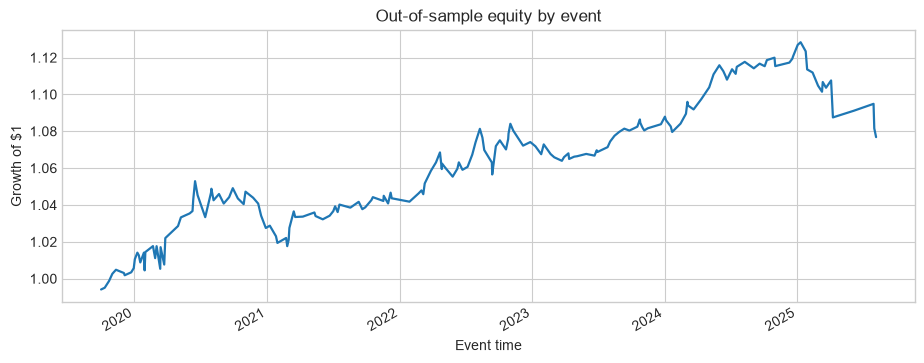

In [20]:
summary = pd.Series({'events predicted': len(test), 'trades taken': len(trades), 'average bet size': trades['bet_size'].mean(), 'positive return rate': (trades['net_return'] > 0).mean(), 'compounded return': trades['equity'].iloc[-1] - 1})
display(summary.to_frame('out-of-sample'))

ax = trades['equity'].plot(figsize=(11, 4), lw=1.6, title='Out-of-sample equity by event')
ax.set(xlabel='Event time', ylabel='Growth of $1')
plt.show()